# RFM Customer Segmentation

## Objective

This analysis segments identifiable customers based on Recency, Frequency, and Monetary value to identify high-value, loyal, emerging, and at-risk customer groups and translate customer behavior into targeted CRM strategies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(
    "/content/cleaned_sales.csv"
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

df.shape

(30030, 16)

In [ ]:
customer_df = df[
    df["CustomerID"].notna()
].copy()

customer_df.shape

(22619, 16)

In [ ]:
customer_df["CustomerID"] = (
    customer_df["CustomerID"]
    .astype(str)
)

In [ ]:
analysis_date = (
    customer_df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

analysis_date

Timestamp('2009-12-15 17:34:00')

In [ ]:
rfm = (
    customer_df
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x:
                (analysis_date - x.max()).days
        ),

        Frequency=(
            "InvoiceNo",
            "nunique"
        ),

        Monetary=(
            "Revenue",
            "sum"
        )
    )
    .reset_index()
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,1,3,90.00
1,12358.0,7,1,1429.83
2,12359.0,10,1,760.69
3,12362.0,14,1,130.00
4,12417.0,5,2,317.60


In [ ]:
rfm.shape
rfm.describe()

,Recency,Frequency,Monetary
count,789.000000,789.000000,789.000000
mean,7.636248,1.376426,622.726743
std,4.059926,1.018360,1550.903887
min,1.000000,1.000000,8.920000
25%,5.000000,1.000000,198.000000
50%,7.000000,1.000000,319.150000
75%,11.000000,1.000000,596.180000
max,14.000000,15.000000,31777.240000


In [ ]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

In [ ]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,1,3,90.00,5,5,1,551
1,12358.0,7,1,1429.83,3,1,5,315
2,12359.0,10,1,760.69,2,1,5,215
3,12362.0,14,1,130.00,1,1,1,111
4,12417.0,5,2,317.60,4,4,3,443


In [ ]:
def assign_segment(row):

    r = row["R_Score"]
    f = row["F_Score"]

    if r >= 4 and f >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and f >= 2:
        return "Potential Loyalists"

    elif r == 5 and f == 1:
        return "New Customers"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2:
        return "Hibernating"

    else:
        return "Needs Attention"

In [ ]:
rfm["Segment"] = rfm.apply(
    assign_segment,
    axis=1
)

rfm["Segment"].value_counts()

,count
Segment,
At Risk,172
Champions,150
Hibernating,144
Potential Loyalists,114
Needs Attention,112
Loyal Customers,69
New Customers,28


In [ ]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .reset_index()
)

In [ ]:
segment_summary["Customer_Share_Pct"] = (
    segment_summary["Customers"]
    / segment_summary["Customers"].sum()
    * 100
).round(2)

segment_summary["Revenue_Share_Pct"] = (
    segment_summary["Total_Revenue"]
    / segment_summary["Total_Revenue"].sum()
    * 100
).round(2)

segment_summary = segment_summary.sort_values(
    "Total_Revenue",
    ascending=False
)

segment_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Share_Pct,Revenue_Share_Pct
1,Champions,150,3.220000,2.406667,1410.681467,211602.22,19.01,43.07
0,At Risk,172,11.843023,1.186047,385.047500,66228.17,21.80,13.48
2,Hibernating,144,11.937500,1.000000,397.021111,57171.04,18.25,11.64
3,Loyal Customers,69,7.130435,1.782609,765.974493,52852.24,8.75,10.76
6,Potential Loyalists,114,3.807018,1.000000,393.107456,44814.25,14.45,9.12
4,Needs Attention,112,7.142857,1.000000,397.343839,44502.51,14.20,9.06
5,New Customers,28,2.142857,1.000000,505.748929,14160.97,3.55,2.88


In [18]:
print("Rows:", df.shape[0])
print("Unique Customer IDs:", df["CustomerID"].nunique())
print("File columns:", df.columns.tolist())

Rows: 30030
Unique Customer IDs: 789
File columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'SourceYear', 'IsCancelled', 'Year', 'Month', 'YearMonth', 'DayOfWeek', 'Hour', 'Revenue']


In [19]:
!ls -lh /content

total 4.1M
-rw-r--r-- 1 root root 4.0M Sep 25 19:46 cleaned_sales.csv
drwxr-xr-x 1 root root 4.0K Sep 16 13:26 sample_data


In [20]:
import pandas as pd

df = pd.read_csv("/content/cleaned_sales.csv")

print("Rows:", df.shape[0])
print("Unique Customer IDs:", df["CustomerID"].nunique())

Rows: 30030
Unique Customer IDs: 789


In [21]:
import pandas as pd

df = pd.read_csv("/content/cleaned_sales.csv")

print("Rows:", df.shape[0])
print("Unique Customer IDs:", df["CustomerID"].nunique())

Rows: 75632
Unique Customer IDs: 1366


In [22]:
import pandas as pd

df = pd.read_csv("/content/cleaned_sales.csv")

print("Rows:", df.shape[0])
print("Unique Customer IDs:", df["CustomerID"].nunique())

Rows: 242221
Unique Customer IDs: 2948


/tmp/ipykernel_2187/1425621986.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/cleaned_sales.csv")


In [23]:
df = pd.read_csv(
    "/content/cleaned_sales.csv"
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

print("Rows:", len(df))
print("Unique customers:", df["CustomerID"].nunique())

/tmp/ipykernel_2187/834359316.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Rows: 1029609
Unique customers: 5878


In [24]:
customer_df = df[
    df["CustomerID"].notna()
].copy()

customer_df["CustomerID"] = (
    customer_df["CustomerID"]
    .astype(str)
)

analysis_date = (
    customer_df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

In [25]:
rfm = (
    customer_df
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (analysis_date - x.max()).days
        ),
        Frequency=(
            "InvoiceNo",
            "nunique"
        ),
        Monetary=(
            "Revenue",
            "sum"
        )
    )
    .reset_index()
)

print(rfm.shape)
rfm.head()

(5878, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [26]:
rfm["CustomerID"] = (
    rfm["CustomerID"]
    .astype(float)
    .astype(int)
    .astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


## RFM Distribution

Before assigning customer segments, the distributions of Recency, Frequency, and Monetary value are reviewed.

In [27]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289554,3008.754787
std,209.338707,13.009435,14731.924115
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,345.115000
50%,96.000000,3.000000,887.390000
75%,380.000000,7.000000,2298.005000
max,739.000000,398.000000,608821.650000


In [29]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

In [30]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [31]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [32]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346,326,12,77556.46,2,5,5
1,12347,2,8,5633.32,5,4,5
2,12348,75,5,2019.40,3,4,4
3,12349,19,4,4428.69,5,3,5
4,12350,310,1,334.40,2,1,2


In [33]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,12,77556.46,2,5,5,255
1,12347,2,8,5633.32,5,4,5,545
2,12348,75,5,2019.40,3,4,4,344
3,12349,19,4,4428.69,5,3,5,535
4,12350,310,1,334.40,2,1,2,212


## Customer Segmentation

Customers are segmented using Recency and Frequency scores to identify commercially meaningful customer groups for CRM and retention strategies.

In [34]:
def assign_segment(row):

    r = row["R_Score"]
    f = row["F_Score"]

    if r >= 4 and f >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and f >= 2:
        return "Potential Loyalists"

    elif r == 5 and f == 1:
        return "New Customers"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2:
        return "Hibernating"

    else:
        return "Needs Attention"

In [35]:
rfm["Segment"] = rfm.apply(
    assign_segment,
    axis=1
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,12,77556.46,2,5,5,255,At Risk
1,12347,2,8,5633.32,5,4,5,545,Champions
2,12348,75,5,2019.40,3,4,4,344,Loyal Customers
3,12349,19,4,4428.69,5,3,5,535,Potential Loyalists
4,12350,310,1,334.40,2,1,2,212,Hibernating


In [36]:
rfm["Segment"].value_counts()

,count
Segment,
Hibernating,1526
Champions,1473
At Risk,825
Needs Attention,765
Potential Loyalists,711
Loyal Customers,524
New Customers,54


In [37]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),

        Avg_Recency=("Recency", "mean"),

        Avg_Frequency=("Frequency", "mean"),

        Avg_Monetary=("Monetary", "mean"),

        Total_Revenue=("Monetary", "sum")
    )
    .reset_index()
)

In [38]:
segment_summary["Customer_Share_Pct"] = (
    segment_summary["Customers"]
    / segment_summary["Customers"].sum()
    * 100
).round(2)

segment_summary["Revenue_Share_Pct"] = (
    segment_summary["Total_Revenue"]
    / segment_summary["Total_Revenue"].sum()
    * 100
).round(2)

In [39]:
segment_summary[
    [
        "Avg_Recency",
        "Avg_Frequency",
        "Avg_Monetary",
        "Total_Revenue"
    ]
] = segment_summary[
    [
        "Avg_Recency",
        "Avg_Frequency",
        "Avg_Monetary",
        "Total_Revenue"
    ]
].round(2)

In [40]:
segment_summary = (
    segment_summary
    .sort_values(
        "Total_Revenue",
        ascending=False
    )
)

segment_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Share_Pct,Revenue_Share_Pct
1,Champions,1473,20.13,15.69,8294.33,12217551.68,25.06,69.08
3,Loyal Customers,524,105.32,8.56,3347.23,1753948.58,8.91,9.92
0,At Risk,825,368.88,4.94,1973.59,1628215.13,14.04,9.21
6,Potential Loyalists,711,25.62,2.59,1151.76,818902.86,12.10,4.63
2,Hibernating,1526,458.75,1.25,435.81,665045.18,25.96,3.76
4,Needs Attention,765,98.60,1.93,761.27,582370.87,13.01,3.29
5,New Customers,54,10.50,1.00,359.75,19426.32,0.92,0.11


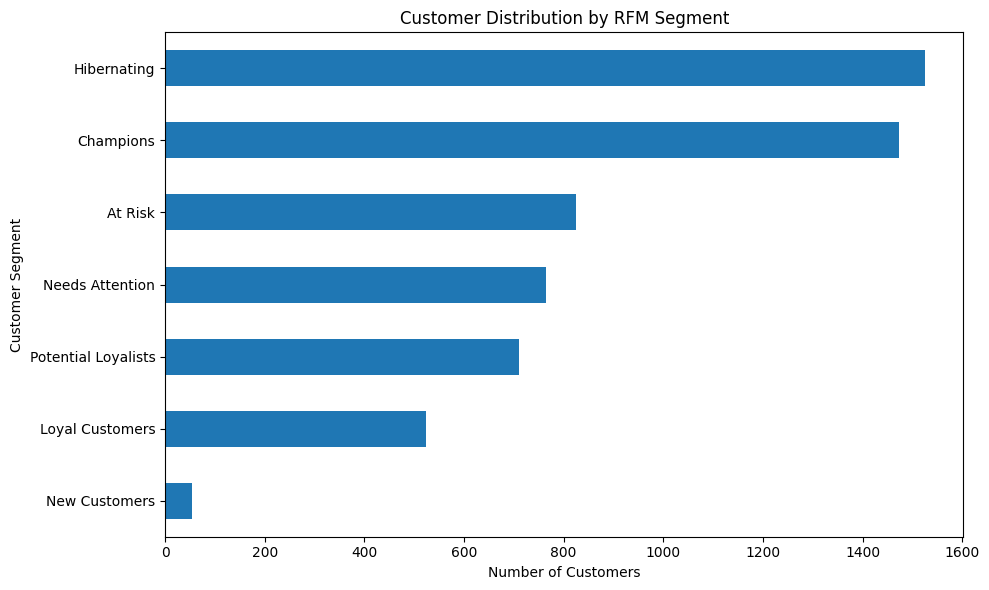

In [41]:
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))

segment_counts.plot(
    kind="barh"
)

plt.title(
    "Customer Distribution by RFM Segment"
)

plt.xlabel(
    "Number of Customers"
)

plt.ylabel(
    "Customer Segment"
)

plt.tight_layout()

plt.show()

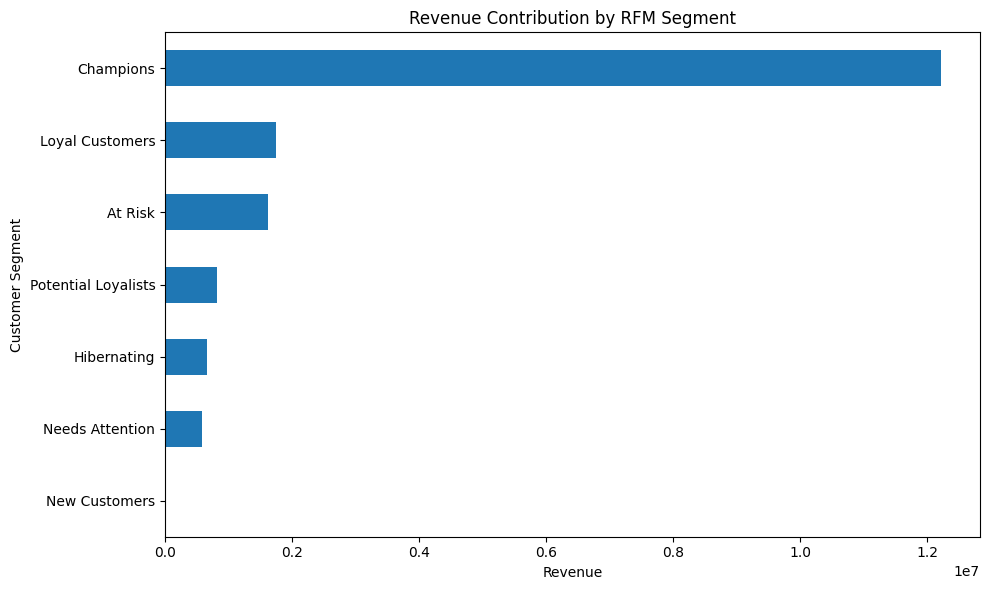

In [42]:
revenue_by_segment = (
    segment_summary
    .set_index("Segment")["Total_Revenue"]
    .sort_values()
)

plt.figure(figsize=(10, 6))

revenue_by_segment.plot(
    kind="barh"
)

plt.title(
    "Revenue Contribution by RFM Segment"
)

plt.xlabel(
    "Revenue"
)

plt.ylabel(
    "Customer Segment"
)

plt.tight_layout()

plt.show()

In [43]:
champions = (
    rfm[
        rfm["Segment"] == "Champions"
    ]
    .sort_values(
        "Monetary",
        ascending=False
    )
)

champions.head(20)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
5692,18102,1,145,608821.65,5,5,5,555,Champions
2277,14646,2,151,528602.52,5,5,5,555,Champions
1789,14156,10,156,313759.82,5,5,5,555,Champions
2538,14911,1,398,295832.39,5,5,5,555,Champions
5050,17450,8,51,246813.09,5,5,5,555,Champions
1331,13694,4,143,196482.81,5,5,5,555,Champions
5109,17511,3,60,175603.55,5,5,5,555,Champions
4295,16684,4,55,147142.77,5,5,5,555,Champions
68,12415,24,28,144458.37,4,5,5,455,Champions
2685,15061,4,127,137818.52,5,5,5,555,Champions


In [44]:
at_risk_high_value = (
    rfm[
        rfm["Segment"] == "At Risk"
    ]
    .sort_values(
        "Monetary",
        ascending=False
    )
)

at_risk_high_value.head(20)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,12,77556.460,2,5,5,255,At Risk
4364,16754,372,29,67502.470,2,5,5,255,At Risk
5442,17850,372,155,56600.080,2,5,5,255,At Risk
743,13093,276,55,54943.650,2,5,5,255,At Risk
3371,15749,235,3,44534.300,2,3,5,235,At Risk
1538,13902,632,5,34095.260,1,4,5,145,At Risk
135,12482,576,29,23691.400,1,5,5,155,At Risk
1698,14063,438,9,22710.200,1,5,5,155,At Risk
3429,15808,306,21,18133.300,2,5,5,255,At Risk
5048,17448,497,46,14523.670,1,5,5,155,At Risk


In [45]:
strategy_map = {
    "Champions":
        "Reward loyalty, offer VIP benefits and early access.",

    "Loyal Customers":
        "Use personalized recommendations and loyalty incentives.",

    "Potential Loyalists":
        "Encourage repeat purchases through targeted offers.",

    "New Customers":
        "Use onboarding campaigns and second-purchase incentives.",

    "At Risk":
        "Launch targeted win-back campaigns, prioritizing historically high-value customers.",

    "Hibernating":
        "Use low-cost reactivation campaigns and selective promotions.",

    "Needs Attention":
        "Use personalized reminders and relevant product recommendations."
}

segment_summary["Recommended_Action"] = (
    segment_summary["Segment"]
    .map(strategy_map)
)

segment_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Share_Pct,Revenue_Share_Pct,Recommended_Action
1,Champions,1473,20.13,15.69,8294.33,12217551.68,25.06,69.08,"Reward loyalty, offer VIP benefits and early a..."
3,Loyal Customers,524,105.32,8.56,3347.23,1753948.58,8.91,9.92,Use personalized recommendations and loyalty i...
0,At Risk,825,368.88,4.94,1973.59,1628215.13,14.04,9.21,"Launch targeted win-back campaigns, prioritizi..."
6,Potential Loyalists,711,25.62,2.59,1151.76,818902.86,12.10,4.63,Encourage repeat purchases through targeted of...
2,Hibernating,1526,458.75,1.25,435.81,665045.18,25.96,3.76,Use low-cost reactivation campaigns and select...
4,Needs Attention,765,98.60,1.93,761.27,582370.87,13.01,3.29,Use personalized reminders and relevant produc...
5,New Customers,54,10.50,1.00,359.75,19426.32,0.92,0.11,Use onboarding campaigns and second-purchase i...


In [46]:
strategy_map = {
    "Champions":
        "Reward loyalty, offer VIP benefits and early access.",

    "Loyal Customers":
        "Use personalized recommendations and loyalty incentives.",

    "Potential Loyalists":
        "Encourage repeat purchases through targeted offers.",

    "New Customers":
        "Use onboarding campaigns and second-purchase incentives.",

    "At Risk":
        "Launch targeted win-back campaigns, prioritizing historically high-value customers.",

    "Hibernating":
        "Use low-cost reactivation campaigns and selective promotions.",

    "Needs Attention":
        "Use personalized reminders and relevant product recommendations."
}

segment_summary["Recommended_Action"] = (
    segment_summary["Segment"]
    .map(strategy_map)
)

segment_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Share_Pct,Revenue_Share_Pct,Recommended_Action
1,Champions,1473,20.13,15.69,8294.33,12217551.68,25.06,69.08,"Reward loyalty, offer VIP benefits and early a..."
3,Loyal Customers,524,105.32,8.56,3347.23,1753948.58,8.91,9.92,Use personalized recommendations and loyalty i...
0,At Risk,825,368.88,4.94,1973.59,1628215.13,14.04,9.21,"Launch targeted win-back campaigns, prioritizi..."
6,Potential Loyalists,711,25.62,2.59,1151.76,818902.86,12.10,4.63,Encourage repeat purchases through targeted of...
2,Hibernating,1526,458.75,1.25,435.81,665045.18,25.96,3.76,Use low-cost reactivation campaigns and select...
4,Needs Attention,765,98.60,1.93,761.27,582370.87,13.01,3.29,Use personalized reminders and relevant produc...
5,New Customers,54,10.50,1.00,359.75,19426.32,0.92,0.11,Use onboarding campaigns and second-purchase i...


In [47]:
rfm.to_csv(
    "/content/rfm_customer_segments.csv",
    index=False
)

segment_summary.to_csv(
    "/content/rfm_segment_summary.csv",
    index=False
)

In [48]:
!ls -lh /content/rfm*.csv

-rw-r--r-- 1 root root 247K Sep 25 22:15 /content/rfm_customer_segments.csv
-rw-r--r-- 1 root root  965 Sep 25 22:15 /content/rfm_segment_summary.csv
